In [1]:
import numpy as np
import os,sys
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from entropy import Entropy

In [3]:
# filename = './nemi_pack_nclust_4_nbr_100_mind_0.0.npy'
filename = './test_clusters.npy'
if os.path.exists(filename):
    lab = np.load(filename)
    print("File loaded successfully.")
else:
    raise FileNotFoundError(f"Error: '{filename}' does not exist. Use dummy=True for dummy data to proceed")    


ent = Entropy(lab)

File loaded successfully.
Using full ensemble


In [4]:
np.unique(lab)

array([0., 1., 2., 3., 4., 5., 6., 7., 8.])

In [5]:
%%time
H = ent.get_entropy()

Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
CPU times: user 586 ms, sys: 30 ms, total: 616 ms
Wall time: 603 ms


In [6]:
((-3/5) * np.log2 (3/5) )/ np.log2(9)

np.float64(0.13949205621537816)

In [7]:
H[0,0]

np.float64(30.630080964467204)

In [8]:
H

array([[30.63008096, 30.63008096, 30.63008096, ..., -0.        ,
        -0.        , -0.        ],
       [30.63008096, 30.63008096, 30.63008096, ..., -0.        ,
        -0.        , -0.        ],
       [43.24867604, 43.24867604, 43.24867604, ..., -0.        ,
        -0.        , -0.        ],
       [30.63008096, 30.63008096, 30.63008096, ..., -0.        ,
        -0.        , -0.        ],
       [30.63008096, 30.63008096, 30.63008096, ..., -0.        ,
        -0.        , -0.        ]])

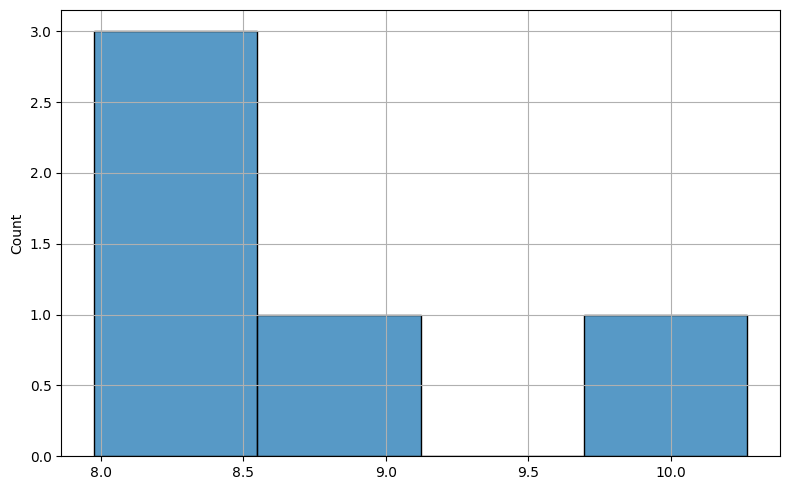

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
# plt.hist(ar.flatten(), bins=50, alpha=0.7, color='green')
# sns.kdeplot(ar.flatten())
sns.histplot(H.mean(axis=1))
# plt.xlabel("Entropy[%]")
# plt.ylabel("PDF")
# plt.title("Entropy distribution across ensemble members")
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
%%time
p = ent.run_parallel()

CPU times: user 0 ns, sys: 309 ms, total: 309 ms
Wall time: 530 ms


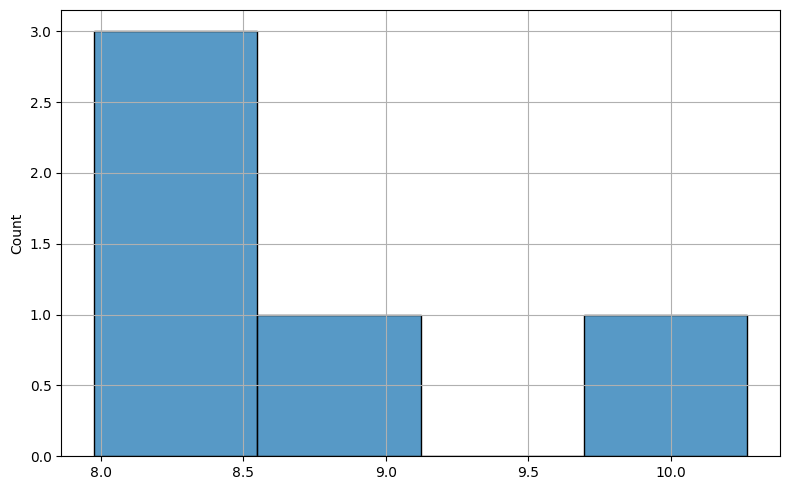

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
# plt.hist(ar.flatten(), bins=50, alpha=0.7, color='green')
# sns.kdeplot(ar.flatten())
sns.histplot(p.mean(axis=1))
# plt.xlabel("Entropy[%]")
# plt.ylabel("PDF")
# plt.title("Entropy distribution across ensemble members")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
%timeit ent.run_parallel()

529 ms ± 40.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
%timeit ent.get_entropy()

Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
Running for..0th member
Running for..1th member
Running for..2th member
Running for..3th member
Running for..4th member
586 ms ± 4.13 ms per loop (mean ± std. d

<Axes: ylabel='Count'>

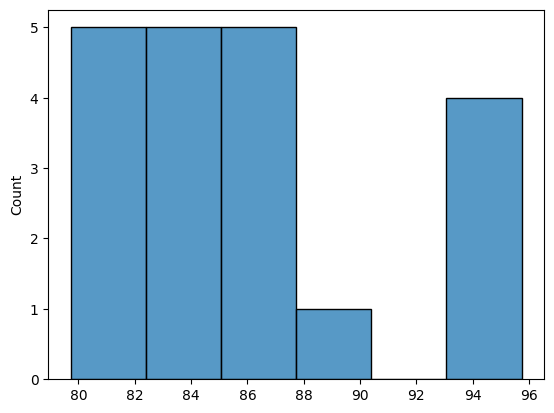

In [16]:
ov = ent.get_overlap().flatten()
import seaborn as sns
sns.histplot(ov)